In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
import pandas as pd
import datetime
import numpy as np
import re
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import cartopy
import cartopy.geodesic as cgeodesic
import xarray as xr
from scipy.stats import gaussian_kde
import warnings

In [2]:
def plot_track_var(data, fig_title):

    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)  

    fig, ax = plt.subplots(figsize=(10., 10.), subplot_kw={'projection': mapcrs})
    ax.add_feature(cartopy.feature.COASTLINE, zorder=17)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False

    cmap = plt.cm.viridis_r
    norm = plt.Normalize(data['slp'].min(), data['slp'].max())

    for name, group in data.groupby('ID'):
        points = group[['lon', 'lat']].values
        color_values = norm(group['slp'])

        for i in range(len(points) - 1):
            line = np.array([points[i], points[i + 1]])
            mid_value = (group['slp'].iloc[i] + group['slp'].iloc[i + 1]) / 2
            ax.plot(line[:, 0], line[:, 1], color=cmap(norm(mid_value)),
                    linewidth=0.5, transform=datacrs, alpha=1)
    
    ax.set_title(fig_title)
    labelin = "hPa"
    plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.05, aspect=50,
                 orientation='horizontal', label=labelin)
    plt.show()


In [3]:
from matplotlib.colors import ListedColormap

def plot_track(data, fig_title):
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)  

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': mapcrs})
    ax.add_feature(cfeature.COASTLINE, zorder=17)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False

    # Generate a colormap with enough colors for each ID
    unique_ids = data['ID'].unique()
    cmap = plt.cm.get_cmap('tab20', len(unique_ids))
    id_to_color = {id: cmap(i) for i, id in enumerate(unique_ids)}

    # Loop through each group and plot the tracks
    for name, group in data.groupby('ID'):
        points = group[['lon', 'lat']].values
        color = id_to_color[name]

        for i in range(len(points) - 1):
            line = np.array([points[i], points[i + 1]])
            ax.plot(line[:, 0], line[:, 1], color=color, linewidth=0.5, transform=datacrs, alpha=1)
    
    # Set the title of the plot
    ax.set_title(fig_title)

    plt.show()


In [4]:
def to_datetime(df):
    df['time'] = df['time'].astype(str)
    df['time'] = pd.to_datetime(df['time'], format='%Y-%m-%d %H:%M:%S')
    return df

def get_season(date):
    year = date.year
    if date.month in [10, 11, 12]:
        return f"{year}-{year+1}"
    elif date.month in [1, 2, 3]:
        return f"{year-1}-{year}"
    else:
        return None 

In [5]:
def calc_speed_dir(data, freq):
    geodesic = cgeodesic.Geodesic()

    distances = []
    speeds = []
    bearings = []
    indices = []

    for name, group in data.groupby('ID'):
        if len(group) < 2:
            continue

        for i in range(len(group) - 1):
            out = geodesic.inverse(
                [group['lon'].iloc[i], group['lat'].iloc[i]],
                [group['lon'].iloc[i+1], group['lat'].iloc[i+1]])

            distance = out[0, 0] * 1e-3  # Convert meters to kilometers
            speed = out[0, 0] / (freq * 3600)  # Calculate speed
            bearing = out[0, 1]  # Azimuth bearing

            distances.append(distance)
            speeds.append(speed)
            bearings.append(bearing)
            indices.append(group.index[i])

    data.loc[indices, 'distance'] = distances
    data.loc[indices, 'speed'] = speeds
    data.loc[indices, 'bearing'] = bearings

    return data

def adjust_bearing(bearing):
    if -180 <= bearing < 0:
        return bearing + 360
    return bearing

In [20]:
data_pls = pd.read_csv('Track/Climatology_Northern_Hemisphere_PL.csv')
data_pls

,ID,step,lon,lat,time,PL_time_step,shear_cat,rel_vort_850_smth,vortex_diameter,theta_trop_mean250,theta_diff_500-sst_mean250,shear_angle_925-500_mean250,shear_strength_925-500_mean250,slp,SST-T_500_mean250,land_dist
0,119790100010,0,-6.00,63.50,1979-01-01 00:00:00,1.0,weak,30.433,356.311486,292.485260,4.700074,284.630035,0.000649,1005.52997,46.797424,83.407516
1,119790100010,1,-6.00,63.25,1979-01-01 01:00:00,1.0,weak,29.720,365.896349,292.327789,4.468158,305.319458,0.000615,1005.50684,47.028522,56.375594
2,119790100010,2,-5.75,63.00,1979-01-01 02:00:00,1.0,weak,29.029,367.311403,292.423187,4.252687,319.822235,0.000711,1005.77747,47.263786,37.144647
3,119790100010,3,-6.25,63.00,1979-01-01 03:00:00,1.0,weak,28.885,358.282911,292.079956,4.354375,327.614990,0.000869,1006.12311,47.186569,27.500000
4,119790100010,4,-6.00,62.75,1979-01-01 04:00:00,1.0,forward,28.905,349.802724,292.278259,4.120545,340.522232,0.001004,1005.59125,47.389069,12.591533
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
342675,220201213780,8,152.25,48.50,2020-12-31 12:00:00,1.0,reverse,26.241,412.834056,291.704773,5.830166,142.151550,0.001718,974.46497,43.109673,57.939996
342676,220201213780,9,153.00,48.00,2020-12-31 13:00:00,1.0,reverse,24.983,413.653954,295.585114,5.559597,148.453583,0.001322,974.67938,43.362415,0.000000
342677,220201213780,10,153.75,47.75,2020-12-31 14:00:00,1.0,weak,24.610,415.181531,292.294800,5.514196,147.222458,0.000961,974.15625,43.379993,18.490087
342678,220201213780,11,154.50,47.50,2020-12-31 15:00:00,1.0,weak,23.922,408.457945,290.172852,5.575976,146.630264,0.000882,974.63123,43.383457,74.314923


In [18]:
winter_pls['ID'].nunique()

11887

In [21]:
data_pls = calc_speed_dir(data_pls, 1)
data_pls['bearing'] = data_pls['bearing'].apply(adjust_bearing)
data_pls = to_datetime(data_pls)
data_pls['season'] = data_pls['time'].apply(get_season)
data_pls = data_pls[data_pls['time'] >= '1982-10-01 00:00:00']
data_pls['time'] = pd.to_datetime(data_pls['time'])
data_pls['month'] = data_pls['time'].dt.month
winter_pls = data_pls[data_pls['month'].isin([10,11, 12, 1, 2, 3])]

In [22]:
northsea_bound = winter_pls[(winter_pls['lon'] >= -6) & (winter_pls['lon'] <= 9) & 
                      (winter_pls['lat'] >= 50) & (winter_pls['lat'] <= 60)]

valid_ids = northsea_bound['ID'].unique()
pls_northsea = winter_pls[winter_pls['ID'].isin(valid_ids)]

In [23]:
pls_northsea.nunique()

ID                                 346
step                                99
lon                                263
lat                                136
time                              7558
PL_time_step                         2
shear_cat                            5
rel_vort_850_smth                 6706
vortex_diameter                   7550
theta_trop_mean250                8098
theta_diff_500-sst_mean250        8162
shear_angle_925-500_mean250       8161
shear_strength_925-500_mean250    8162
slp                               7627
SST-T_500_mean250                 8141
land_dist                         2453
distance                          1654
speed                             1654
bearing                           2338
season                              39
month                                6
dtype: int64

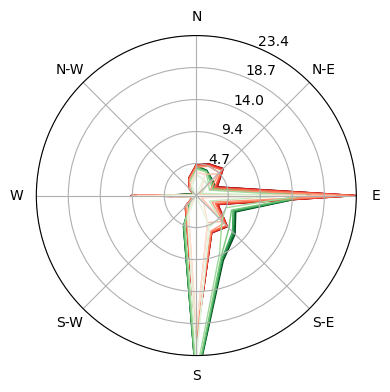

In [10]:
from windrose import WindroseAxes
import matplotlib.cm as cm
trx_dir_all = winter_pls.dropna(subset=['bearing', 'speed'])
northsea_bound = trx_dir_all[(trx_dir_all['lon'] >= -4) & (trx_dir_all['lon'] <= 10) & 
                      (trx_dir_all['lat'] >= 50) & (trx_dir_all['lat'] <= 60)]
trx_dir_north = northsea_bound.dropna(subset=['bearing', 'speed'])

fig = plt.figure(figsize=(4, 4))  # Adjust figure size for better visibility
ax = WindroseAxes.from_ax(fig=fig)

#ax.contourf(trx_dir_all['bearing'].values, trx_dir_all['speed'].values, bins=np.arange(0, 45, 5), cmap=plt.cm.Blues, alpha=0.9, normed=True)
ax.contour(trx_dir_all['bearing'].values, trx_dir_all['speed'].values, bins=np.arange(0, 45, 5), cmap=cm.Reds, lw=1, alpha=1, normed=True)

#ax.contourf(trx_dir_north['bearing'].values, trx_dir_north['speed'].values, bins=np.arange(0, 45, 5), cmap=plt.cm.Reds, alpha=0.4, normed=True)
ax.contour(trx_dir_north['bearing'].values, trx_dir_north['speed'].values, bins=np.arange(0, 45, 5), cmap=cm.Greens, lw=1, alpha=1, normed=True)

#ax.set_legend(title="Storm propagation \nspeed (km/h)", loc="lower left")
plt.show()

In [11]:
pls_northsea['ID'].nunique()

346

/tmp/ipykernel_521/681431824.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_ids))


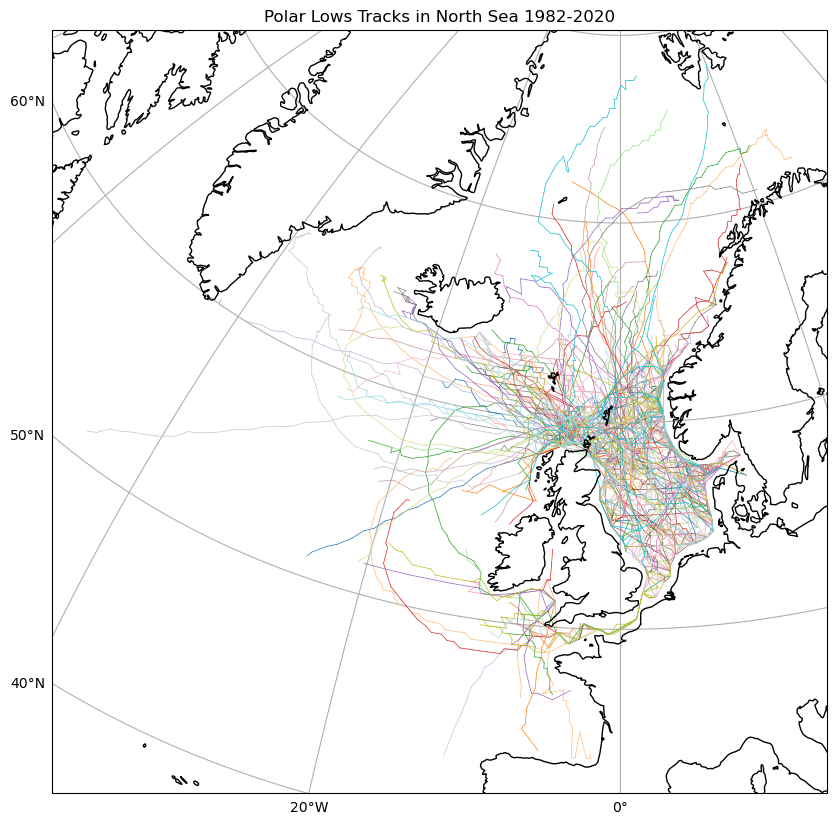

In [12]:
plot_track(pls_northsea, "Polar Lows Tracks in North Sea 1982-2020")

In [13]:
pls_northsea['slp'].min()

944.065

/tmp/ipykernel_521/1253290574.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_ids))
/tmp/ipykernel_521/1253290574.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_ids))
/tmp/ipykernel_521/1253290574.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_ids))
/tmp/ipykernel_521/1253290574.py:25: MatplotlibDeprecationWarning: The get_cmap funct

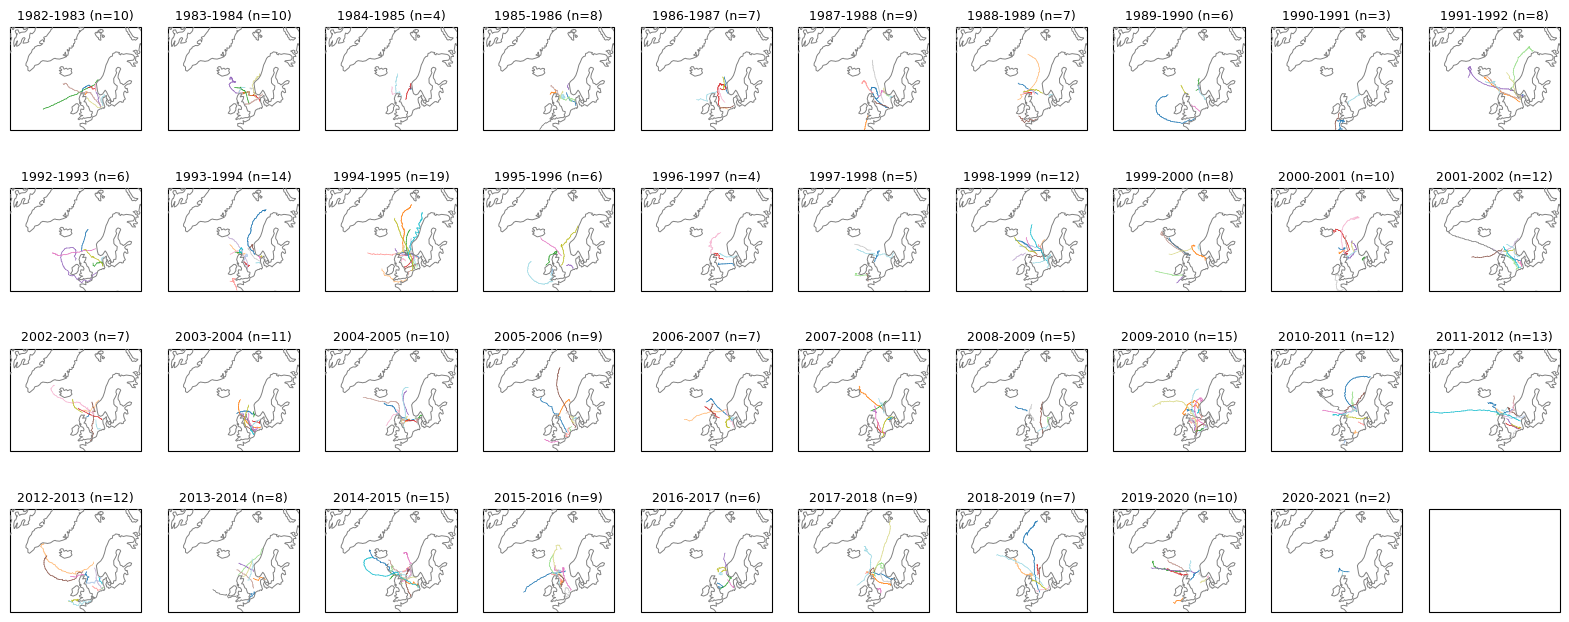

In [15]:
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

datacrs = ccrs.PlateCarree()
mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)
boundary = [-40, 25, 80, 45]

fig, axs = plt.subplots(4, 10, sharey=True, sharex=True, figsize=(20., 8.), subplot_kw={'projection': mapcrs})
axs = axs.ravel()

for iyear, ax in enumerate(axs):
    year = 1982 + iyear
    trx_season = pls_northsea[pls_northsea['season'] == f'{year}-{year+1}']
    if trx_season.empty:
        continue

    season = trx_season['season'].iloc[0]
    n_storm = trx_season['ID'].nunique()

    ax.set_extent(boundary, crs=datacrs)
    ax.coastlines(resolution='110m', zorder=17, linewidth=0.7, color='grey')

    # Generate a colormap with enough colors for each ID
    unique_ids = trx_season['ID'].unique()
    cmap = plt.cm.get_cmap('tab20', len(unique_ids))
    id_to_color = {id: cmap(i) for i, id in enumerate(unique_ids)}

    # Loop through each group and plot the tracks
    for name, group in trx_season.groupby('ID'):
        points = group[['lon', 'lat']].values
        color = id_to_color[name]

        for i in range(len(points) - 1):
            line = np.array([points[i], points[i + 1]])
            ax.plot(line[:, 0], line[:, 1], color=color, linewidth=0.5, transform=datacrs, alpha=1)

    ax.set_title(f'{season} (n={n_storm})', fontsize=9)

plt.show()

In [14]:
filtered_pls = pls_northsea.drop_duplicates(subset=['ID'])
season_counts = filtered_pls['season'].value_counts().sort_index()
season_counts

season
1982-1983    10
1983-1984    10
1984-1985     4
1985-1986     8
1986-1987     7
1987-1988     9
1988-1989     7
1989-1990     6
1990-1991     3
1991-1992     8
1992-1993     6
1993-1994    14
1994-1995    19
1995-1996     6
1996-1997     4
1997-1998     5
1998-1999    12
1999-2000     8
2000-2001    10
2001-2002    12
2002-2003     7
2003-2004    11
2004-2005    10
2005-2006     9
2006-2007     7
2007-2008    11
2008-2009     5
2009-2010    15
2010-2011    12
2011-2012    13
2012-2013    12
2013-2014     8
2014-2015    15
2015-2016     9
2016-2017     6
2017-2018     9
2018-2019     7
2019-2020    10
2020-2021     2
Name: count, dtype: int64

## Closure date

In [20]:
closdata = pd.read_csv('northsea/closure_date_window.csv')
closdata['Closure Dates'] = closdata['Closure Dates'].astype(str)
closdata['Window -2'] = closdata['Window -2'].astype(str)
closdata['Window +2'] = closdata['Window +2'].astype(str)
closdata['Closure Dates'] = pd.to_datetime(closdata['Closure Dates'], format='%d/%m/%Y')
closdata['Window -2'] = pd.to_datetime(closdata['Window -2'], format='%d/%m/%Y')
closdata['Window +2'] = pd.to_datetime(closdata['Window +2'], format='%d/%m/%Y', errors='coerce')
closdata['Window -1'] = closdata['Closure Dates'] - pd.DateOffset(1)
closdata['Window +1'] = closdata['Closure Dates'] + pd.DateOffset(1)
closdata

,FD Closure Number,Closure Dates,Window -2,Window +2,Type,Window -1,Window +1
0,1,1983-02-01,1983-01-30,1983-02-03,Tidal,1983-01-31,1983-02-02
1,2,1985-12-26,1985-12-24,1985-12-28,Fluvial,1985-12-25,1985-12-27
2,3,1987-03-29,1987-03-27,1987-03-31,Combined,1987-03-28,1987-03-30
3,4,1988-12-24,1988-12-22,1988-12-26,Tidal,1988-12-23,1988-12-25
4,5,1990-02-12,1990-02-10,1990-02-14,Combined,1990-02-11,1990-02-13
...,...,...,...,...,...,...,...
216,217,2024-03-11,2024-03-09,2024-03-13,Tidal,2024-03-10,2024-03-12
217,218,2024-03-14,2024-03-12,2024-03-16,Combined,2024-03-13,2024-03-15
218,219,2024-03-14,2024-03-12,2024-03-16,Combined,2024-03-13,2024-03-15
219,220,2024-04-08,2024-04-06,2024-04-10,Tidal,2024-04-07,2024-04-09


In [22]:
# Initialize an empty DataFrame to store the filtered results
filtered_trx = pd.DataFrame(columns=['time', 'ID', 'closure_ID', 'closure_type', 'closure_date'])

# Ensure the 'date' column in trx_all is in datetime format
pls_northsea['time'] = pd.to_datetime(pls_northsea['time'])

# Iterate over each date window and filter the events
for _, row in closdata.iterrows():
    closure_id = row['FD Closure Number']
    closure_date = row['Closure Dates']
    closure_type = row['Type']
    start_date = pd.to_datetime(row['Window -1'])
    end_date = pd.to_datetime(row['Window +1'])

    # Filter events that have positions only inside this boundary 
    northsea_bound = pls_northsea[(pls_northsea['lon'] >= -5) & (pls_northsea['lon'] <= 9) & 
                             (pls_northsea['lat'] >= 50) & (pls_northsea['lat'] <= 65)]
    
    # Filter events that happen inside this boundary during the current date window
    valid_ids = northsea_bound[(northsea_bound['time'] >= start_date) & 
                               (northsea_bound['time'] <= end_date)]['ID'].unique()
    
    # Filter the original dataframe to get the final result
    trx_bound = pls_northsea[pls_northsea['ID'].isin(valid_ids)]
    filtered_window_trx = trx_bound[['time', 'ID']].copy()
    
    # Add the closure ID to the filtered events
    filtered_window_trx['closure_ID'] = closure_id
    filtered_window_trx['closure_date'] = closure_date
    filtered_window_trx['closure_type'] = closure_type
    
    # Concatenate the filtered results
    filtered_trx = pd.concat([filtered_trx, filtered_window_trx], ignore_index=True)

# Reset index of the filtered events DataFrame
filtered_trx.reset_index(drop=True, inplace=True)

# Display the filtered events
filtered_trx

,time,ID,closure_ID,closure_type,closure_date
0,1983-01-28 23:00:00,119830115960,1,Tidal,1983-02-01
1,1983-01-29 00:00:00,119830115960,1,Tidal,1983-02-01
2,1983-01-29 01:00:00,119830115960,1,Tidal,1983-02-01
3,1983-01-29 02:00:00,119830115960,1,Tidal,1983-02-01
4,1983-01-29 03:00:00,119830115960,1,Tidal,1983-02-01
...,...,...,...,...,...
1384,2020-03-12 14:00:00,120200306680,192,Combined,2020-03-13
1385,2020-03-12 15:00:00,120200306680,192,Combined,2020-03-13
1386,2020-03-12 16:00:00,120200306680,192,Combined,2020-03-13
1387,2020-03-12 17:00:00,120200306680,192,Combined,2020-03-13


In [23]:
print('all storm:', filtered_trx['ID'].nunique())

all storm: 34


In [24]:
filtered_ids = filtered_trx['ID'].unique()
trx_filterbyclos = pls_northsea[pls_northsea['ID'].isin(filtered_ids)]

trx_filterbyclos.head()

,ID,step,lon,lat,time,PL_time_step,shear_cat,rel_vort_850_smth,vortex_diameter,theta_trop_mean250,theta_diff_500-sst_mean250,shear_angle_925-500_mean250,shear_strength_925-500_mean250,slp,SST-T_500_mean250,land_dist,season
19228,119830115960,0,-18.00,61.00,1983-01-28 23:00:00,1.0,left,33.587,392.238382,294.391876,7.221291,231.709518,0.001584,978.94373,43.452099,247.500000,1982-1983
19229,119830115960,1,-17.50,60.75,1983-01-29 00:00:00,1.0,left,32.680,391.951031,293.898529,7.169972,237.828995,0.001415,980.12811,43.566277,275.328087,1982-1983
19230,119830115960,2,-17.25,60.75,1983-01-29 01:00:00,1.0,left,31.907,390.104057,293.576416,7.017789,242.530228,0.001337,981.20435,43.738354,276.310009,1982-1983
19231,119830115960,3,-17.00,61.00,1983-01-29 02:00:00,1.0,left,31.261,400.577025,293.655640,7.084365,244.235077,0.001380,982.37183,43.725201,250.710976,1982-1983
19232,119830115960,4,-16.75,61.25,1983-01-29 03:00:00,1.0,left,32.755,395.235787,293.927002,7.115074,241.680717,0.001455,983.34436,43.717129,226.272706,1982-1983


In [27]:
def plot_track_2(data_trx, filtered_trx):  
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50) 
    n_storm = data_trx['ID'].nunique()

    # Define color mapping for each closure type
    color_mapping = {
        'Combined': 'tab:blue',
        'Fluvial': 'tab:orange',
        'Tidal': 'tab:green'
    }

    # Assign a color to each unique_identifier based on its closure type
    unique_ids = filtered_trx['ID'].unique()
    identifier_colors = {uid: color_mapping[filtered_trx[filtered_trx['ID'] == uid]['closure_type'].values[0]] for uid in unique_ids}


    fig, ax = plt.subplots(figsize=(7., 7.), subplot_kw={'projection': mapcrs})
    ax.coastlines(resolution='110m', zorder=17, linewidth=0.7, color='black')
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False

    # Processing each group
    for name, group in data_trx.groupby('ID'):
        points = group[['lon', 'lat']].values
        storm_color = identifier_colors[name]  # Get the color for this storm

        for i in range(len(points) - 1):
            line = np.array([points[i], points[i + 1]])
            ax.plot(line[:, 0], line[:, 1], color=storm_color, linewidth=0.7, transform=datacrs)
    ax.legend()
    ax.set_title(f"Polar Lows within Thames Barrier Closure Date Window (n={n_storm})")

    plt.show()

In [33]:
def plot_track_3(data_trx, filtered_trx):  
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50) 
    boundary = [-40, 25, 85, 45]
    n_storm = data_trx['ID'].nunique()

    # Define color mapping for each closure type
    color_mapping = {
        'Fluvial': 'tab:orange',
        'Combined': 'tab:blue',
        'Tidal': 'tab:green'
    }

    fig, axs = plt.subplots(1, 3, figsize=(10., 8.), subplot_kw={'projection': mapcrs})
    fig.subplots_adjust(hspace=0.25)
    
    closure_types = ['Combined', 'Fluvial', 'Tidal']
    
    for i, closure_type in enumerate(closure_types):
        ax = axs[i]
        ax.set_extent(boundary, crs=datacrs)
        ax.coastlines(resolution='110m', zorder=17, linewidth=0.7, color='black')
        gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
        gl.top_labels = False
        gl.right_labels = False
        
        # Filter data for the current closure type
        ids_to_plot = filtered_trx[filtered_trx['closure_type'] == closure_type]['ID']
        data_to_plot = data_trx[data_trx['ID'].isin(ids_to_plot)]
        
        # Processing each group
        for name, group in data_to_plot.groupby('ID'):
            points = group[['lon', 'lat']].values
            storm_color = color_mapping[closure_type]  # Get the color for this storm

            for j in range(len(points) - 1):
                line = np.array([points[j], points[j + 1]])
                ax.plot(line[:, 0], line[:, 1], color=storm_color,
                        linewidth=0.7, transform=datacrs)
                
        unique_tracks = len(ids_to_plot.unique())
        ax.set_title(f"Polar Lows {closure_type} Closures (n={unique_tracks})", fontsize=10)

    plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


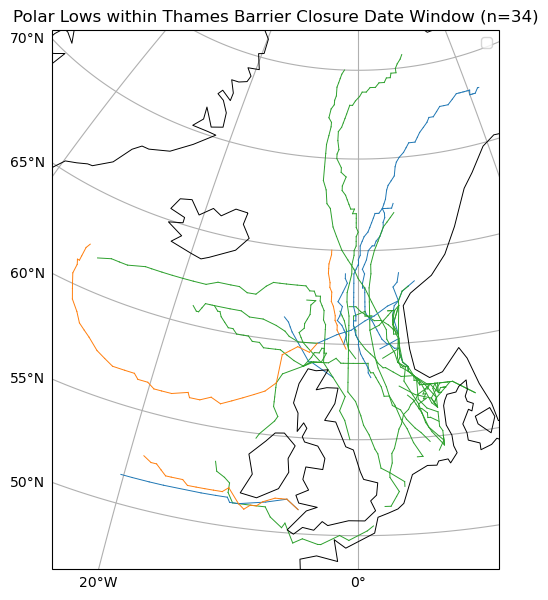

In [28]:
import warnings
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

plot_track_2(trx_filterbyclos, filtered_trx)

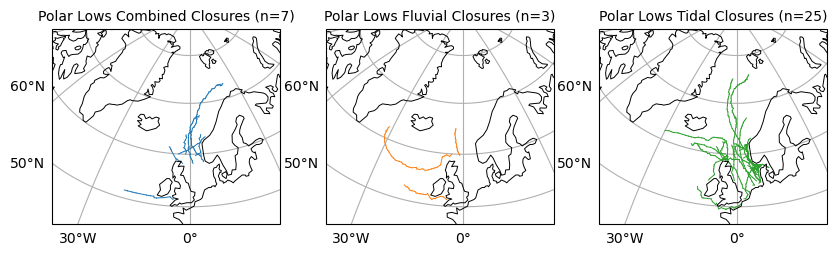

In [34]:
import warnings
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

plot_track_3(trx_filterbyclos, filtered_trx)

In [ ]:
trx_filterbyclos['ID']

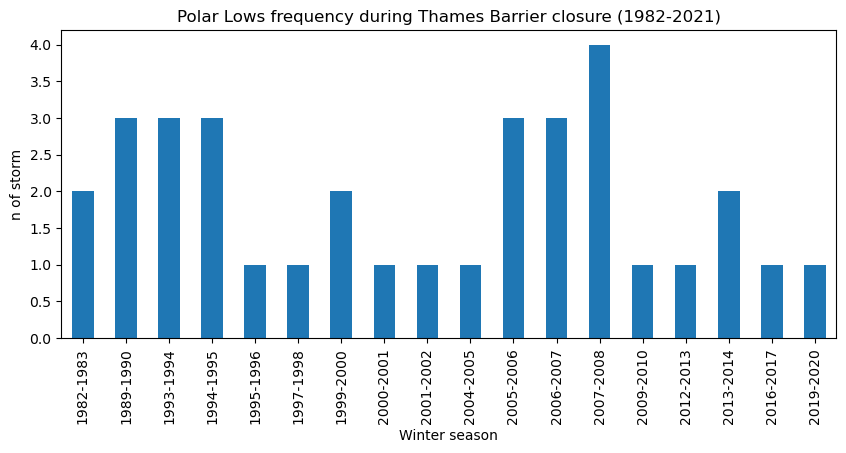

In [35]:
filtered_trx

filtered_storm = trx_filterbyclos.drop_duplicates(subset=['ID'])
season_counts = filtered_storm['season'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10., 4.))
season_counts.plot(kind='bar', color='tab:blue')
plt.title('Polar Lows frequency during Thames Barrier closure (1982-2021)')
plt.xlabel('Winter season')
plt.ylabel('n of storm')
plt.xticks(rotation=90)
plt.legend()
plt.show()

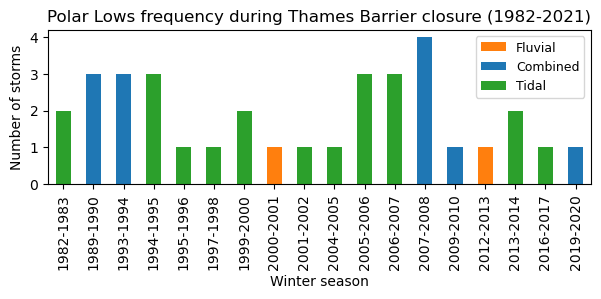

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

# Remove duplicate storms based on 'ID'
filtered_closure = filtered_trx.drop_duplicates(subset=['ID'])
filtered_storm = trx_filterbyclos.drop_duplicates(subset=['ID'])

# Merge filtered_storm with filtered_trx to get the 'closure_type' information
merged_df = pd.merge(filtered_storm, filtered_closure[['ID', 'closure_type']], on='ID', how='left')

# Count the number of storms per season
season_counts = merged_df['season'].value_counts().sort_index()

# Create a color map for closure types
closure_type_colors = {
    'Fluvial': 'tab:orange',
    'Combined': 'tab:blue',
    'Tidal': 'tab:green'
}

# Map the colors to the merged DataFrame
merged_df['color'] = merged_df['closure_type'].map(closure_type_colors)

# Get the colors for each bar in the bar chart
colors = [merged_df[merged_df['season'] == season]['color'].iloc[0] for season in season_counts.index]

# Create a bar plot of the storm frequency by season with colors based on closure_type
fig, ax = plt.subplots(figsize=(7., 2.))
season_counts.plot(kind='bar', color=colors, ax=ax)

ax.set_title('Polar Lows frequency during Thames Barrier closure (1982-2021)')
ax.set_xlabel('Winter season')
ax.set_ylabel('Number of storms')
ax.set_xticks(range(len(season_counts)))
ax.set_xticklabels(season_counts.index, rotation=90)
# Create custom legend
legend_elements = [Patch(facecolor=color, label=closure_type) for closure_type, color in closure_type_colors.items()]
ax.legend(handles=legend_elements, fontsize=9)

# Display the plot
plt.show()
